In [4]:
# ===================== CELL 1: SETUP & IMPORTS =====================
import os
import sys
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

# Link to the custom dataset file in the parent directory
sys.path.append('..')
from dataset import TimepieceDataset

# Initialize compute hardware
processing_device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Active compute hardware: {processing_device}")
import os
print(os.cpu_count())

Active compute hardware: cuda
32


In [5]:
# ===================== CELL 2: V1 MODEL (BASIC U-NET) =====================
class BasicHandRemover(nn.Module):
    def __init__(self):
        super(BasicHandRemover, self).__init__()
        
        # Downsampling path
        self.down1 = self._build_layer(3, 64)
        self.down2 = self._build_layer(64, 128)
        self.down3 = self._build_layer(128, 256)
        self.max_pool = nn.MaxPool2d(2, 2)
        
        # Upsampling path
        self.up_scale2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.up_layer2 = self._build_layer(256 + 128, 128) 
        
        self.up_scale1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.up_layer1 = self._build_layer(128 + 64, 64)   
        
        self.output_conv = nn.Conv2d(64, 3, kernel_size=1)

    def _build_layer(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, img_tensor):
        # Down
        d1 = self.down1(img_tensor)
        p1 = self.max_pool(d1)
        
        d2 = self.down2(p1)
        p2 = self.max_pool(d2)
        
        d3 = self.down3(p2) 
        
        # Up
        u2 = self.up_scale2(d3)
        if u2.size() != d2.size():
            u2 = F.interpolate(u2, size=d2.shape[2:])
        u2 = torch.cat([u2, d2], dim=1)
        u2_out = self.up_layer2(u2)
        
        u1 = self.up_scale1(u2_out)
        if u1.size() != d1.size():
            u1 = F.interpolate(u1, size=d1.shape[2:])
        u1 = torch.cat([u1, d1], dim=1)
        u1_out = self.up_layer1(u1)
        
        return torch.sigmoid(self.output_conv(u1_out))

In [6]:
# ===================== CELL 3: V1 TRAINING PIPELINE (ULTRA-FAST VERSION) =====================

def execute_basic_training(target_dir="../datasets", max_epochs=20, b_size=32, px_size=128, learn_rate=0.001):
    print(f"Hardware assigned: {processing_device}")

    # 1. הקטנת הרזולוציה ל-128x128 
    vision_transforms = transforms.Compose([
        transforms.Resize((px_size, px_size)), 
        transforms.ToTensor(),
    ])

    # שימוש במחלקת הנתונים הקיימת שלך (On-the-Fly Augmentation)
    train_data = TimepieceDataset(base_path=target_dir, partition='train', transforms_pipeline=vision_transforms)
    test_data  = TimepieceDataset(base_path=target_dir, partition='test', transforms_pipeline=vision_transforms)
    
    # 2. שימוש ב-4 Workers ו-pin_memory לטעינה מהירה
    loader_train = DataLoader(train_data, batch_size=b_size, shuffle=True, num_workers=4, pin_memory=True)
    loader_test  = DataLoader(test_data, batch_size=4, shuffle=True, num_workers=4, pin_memory=True) 

    unet_model = BasicHandRemover().to(processing_device)
    loss_fn = nn.MSELoss() 
    adam_opt = optim.Adam(unet_model.parameters(), lr=learn_rate)

    # 3. אתחול ה-Scaler עבור Mixed Precision (AMP)
    scaler = torch.amp.GradScaler('cuda')

    os.makedirs('checkpoints', exist_ok=True)
    lowest_loss = float('inf')

    print(f"Initiating V1 Basic Eraser Training (ULTRA-FAST Mode, {px_size}px, Batch={b_size})...")
    
    epoch_progress = tqdm(range(max_epochs), desc="V1 epochs")
    for epoch_idx in epoch_progress:
        unet_model.train()
        accumulated_loss = 0.0
        
        batch_progress = tqdm(loader_train, desc=f"V1 epoch {epoch_idx + 1}/{max_epochs}", leave=False)
        for data_batch in batch_progress:
            dirty_imgs = data_batch['analog_img'].to(processing_device)
            clean_targets = data_batch['clean_img'].to(processing_device)
            
            adam_opt.zero_grad()
            
            # הפעלת Autocast שמבצע חישובים בדיוק של 16-ביט היכן שאפשר
            with torch.amp.autocast('cuda'):
                predictions = unet_model(dirty_imgs)
                batch_loss = loss_fn(predictions, clean_targets)
                
            # עדכון המשקולות בעזרת ה-Scaler
            scaler.scale(batch_loss).backward()
            scaler.step(adam_opt)
            scaler.update()
            
            accumulated_loss += batch_loss.item()
            batch_progress.set_postfix(loss=f"{batch_loss.item():.5f}")

        mean_loss = accumulated_loss / len(loader_train)

        # 4. ביצוע ולידציה רק כל 5 אפוקים או באפוק האחרון
        if (epoch_idx + 1) % 5 == 0 or epoch_idx == max_epochs - 1:
            unet_model.eval()
            val_loss = 0.0
            with torch.no_grad():
                with torch.amp.autocast('cuda'): # גם הולידציה רצה עם AMP
                    for val_batch in loader_test:
                        v_dirty = val_batch['analog_img'].to(processing_device)
                        v_clean = val_batch['clean_img'].to(processing_device)
                        v_pred = unet_model(v_dirty)
                        val_loss += loss_fn(v_pred, v_clean).item()
                        
            mean_val = val_loss / len(loader_test)
            epoch_progress.set_postfix(train=f"{mean_loss:.5f}", val=f"{mean_val:.5f}")
            print(f"Epoch [{epoch_idx+1:>3}/{max_epochs}] | Train MSE: {mean_loss:.5f} | Val MSE: {mean_val:.5f}")

            # שומרים את המודל רק אם יש שיפור
            if mean_val < lowest_loss:
                lowest_loss = mean_val
                torch.save(unet_model.state_dict(), "checkpoints/clock_eraser_basic_best.pth")
                print("  --> Checkpoint saved!")

            # אופציונלי: הצגת תמונות כל 5 אפוקים
            # show_v1_samples(unet_model, loader_test, processing_device)
            
        else:
             # מדפיסים רק את תוצאות האימון באפוקים שבהם אין ולידציה
            epoch_progress.set_postfix(train=f"{mean_loss:.5f}")
            print(f"Epoch [{epoch_idx+1:>3}/{max_epochs}] | Train MSE: {mean_loss:.5f}")


# פונקציית תצוגה (ללא שינוי, השארתי לנוחות)
def show_v1_samples(network, data_loader, hardware):
    network.eval()
    with torch.no_grad():
        sample_batch = next(iter(data_loader))
        input_dirty = sample_batch['analog_img'].to(hardware)
        target_clean = sample_batch['clean_img'].to(hardware)
        generated_clean = network(input_dirty)
        
        fig, axs = plt.subplots(3, 3, figsize=(10, 10))
        for col in range(3):
            if col >= len(input_dirty): break
            axs[0, col].imshow(input_dirty[col].cpu().permute(1, 2, 0))
            axs[0, col].set_title("Original (With Hands)")
            axs[0, col].axis('off')
            
            axs[1, col].imshow(generated_clean[col].cpu().permute(1, 2, 0))
            axs[1, col].set_title("Network Prediction")
            axs[1, col].axis('off')
            
            axs[2, col].imshow(target_clean[col].cpu().permute(1, 2, 0))
            axs[2, col].set_title("Target (Clean Face)")
            axs[2, col].axis('off')
        plt.show()
    

In [7]:
#if __name__ == "__main__":
        #execute_basic_training(target_dir="../datasets", max_epochs=50, b_size=32, px_size=128)

# V2 

In [8]:
# ===================== CELL 4: V2 ADVANCED MODEL =====================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.dual_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, img_tensor):
        return self.dual_conv(img_tensor)


class AdvancedClockCleaner(nn.Module):
    """
    4-Tier U-Net Architecture optimized for artifact removal.
    """
    def __init__(self, filter_base=64):
        super().__init__()
        
        self.encode1 = DoubleConv(3, filter_base)
        self.encode2 = DoubleConv(filter_base, filter_base * 2)
        self.encode3 = DoubleConv(filter_base * 2, filter_base * 4)
        self.encode4 = DoubleConv(filter_base * 4, filter_base * 8)
        self.downsample = nn.MaxPool2d(2, 2)

        self.bridge = DoubleConv(filter_base * 8, filter_base * 8)

        self.up_trans4 = nn.ConvTranspose2d(filter_base * 8, filter_base * 8, kernel_size=2, stride=2)
        self.decode4 = DoubleConv(filter_base * 8 + filter_base * 8, filter_base * 4)

        self.up_trans3 = nn.ConvTranspose2d(filter_base * 4, filter_base * 4, kernel_size=2, stride=2)
        self.decode3 = DoubleConv(filter_base * 4 + filter_base * 4, filter_base * 2)

        self.up_trans2 = nn.ConvTranspose2d(filter_base * 2, filter_base * 2, kernel_size=2, stride=2)
        self.decode2 = DoubleConv(filter_base * 2 + filter_base * 2, filter_base)

        self.up_trans1 = nn.ConvTranspose2d(filter_base, filter_base, kernel_size=2, stride=2)
        self.decode1 = DoubleConv(filter_base + filter_base, filter_base)

        self.output_mapping = nn.Sequential(
            nn.Conv2d(filter_base, 3, kernel_size=1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        enc1_out = self.encode1(x)
        enc2_out = self.encode2(self.downsample(enc1_out))
        enc3_out = self.encode3(self.downsample(enc2_out))
        enc4_out = self.encode4(self.downsample(enc3_out))
        
        mid_bridge = self.bridge(self.downsample(enc4_out))

        dec4_in = torch.cat([self._align_sizes(self.up_trans4, mid_bridge, enc4_out), enc4_out], dim=1)
        dec4_out = self.decode4(dec4_in)
        
        dec3_in = torch.cat([self._align_sizes(self.up_trans3, dec4_out, enc3_out), enc3_out], dim=1)
        dec3_out = self.decode3(dec3_in)
        
        dec2_in = torch.cat([self._align_sizes(self.up_trans2, dec3_out, enc2_out), enc2_out], dim=1)
        dec2_out = self.decode2(dec2_in)
        
        dec1_in = torch.cat([self._align_sizes(self.up_trans1, dec2_out, enc1_out), enc1_out], dim=1)
        dec1_out = self.decode1(dec1_in)

        return self.output_mapping(dec1_out)

    @staticmethod
    def _align_sizes(upsample_func, current_tensor, skip_tensor):
        current_tensor = upsample_func(current_tensor)
        if current_tensor.shape != skip_tensor.shape:
            current_tensor = F.interpolate(current_tensor, size=skip_tensor.shape[2:], mode='bilinear', align_corners=False)
        return current_tensor

In [9]:
# ===================== CELL 5: V2 ADVANCED LOSS =====================
class DetailPreservingLoss(nn.Module):
    """
    Applies aggressive L1 weighting to the regions where hands are detected,
    and applies a Sobel filter loss to maintain the sharpness of clock markers.
    """
    def __init__(self, hand_wt=5.0, edge_wt=2.0):
        super().__init__()
        self.hand_wt = hand_wt
        self.edge_wt = edge_wt

        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer('filter_x', sobel_x)
        self.register_buffer('filter_y', sobel_y)

    def _apply_sobel(self, img_batch):
        grayscale = 0.299 * img_batch[:,0:1] + 0.587 * img_batch[:,1:2] + 0.114 * img_batch[:,2:3]
        edge_x = F.conv2d(grayscale, self.filter_x, padding=1)**2
        edge_y = F.conv2d(grayscale, self.filter_y, padding=1)**2
        return torch.sqrt(edge_x + edge_y + 1e-6)

    def forward(self, network_out, target_bg, dirty_img):
        diff_map = (dirty_img - target_bg).abs().sum(dim=1, keepdim=True)
        hand_locations = (diff_map > 0.05).float()

        # Weighted L1 Loss
        l1_diff = F.l1_loss(network_out, target_bg, reduction='none')
        attention_weights = 1.0 + (self.hand_wt - 1.0) * hand_locations
        loss_pixels = (l1_diff * attention_weights).mean()

        # Sobel Structure Loss
        loss_structure = F.l1_loss(self._apply_sobel(network_out), self._apply_sobel(target_bg))

        return loss_pixels + self.edge_wt * loss_structure

In [10]:
# ===================== LOSS =====================

class EraserLoss(nn.Module):
    """
    Weighted L1 loss: hand pixels get 5× more gradient signal.
    Also adds an edge-preservation term (Sobel) so tick marks
    and numbers on the clock face remain sharp after erasing.
    """
    def __init__(self, hand_weight=5.0, edge_weight=2.0):
        super().__init__()
        self.hw = hand_weight
        self.ew = edge_weight

        sx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sy = torch.tensor([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer('sx', sx)
        self.register_buffer('sy', sy)

    def _sobel(self, img):
        gray = 0.299*img[:,0:1] + 0.587*img[:,1:2] + 0.114*img[:,2:3]
        return torch.sqrt(
            F.conv2d(gray, self.sx, padding=1)**2 +
            F.conv2d(gray, self.sy, padding=1)**2 + 1e-6
        )

    def forward(self, pred, clean, analog):
        """
        pred   : model output             (B, 3, H, W)  in [0,1]
        clean  : target clean image       (B, 3, H, W)  in [0,1]
        analog : original (with hands)    (B, 3, H, W)  in [0,1]
        """
        # Identify hand pixels: where analog differs from clean
        diff = (analog - clean).abs().sum(dim=1, keepdim=True)
        hand_mask = (diff > 0.05).float()

        # Pixel loss — weighted
        pixel_loss = F.l1_loss(pred, clean, reduction='none')
        weight_map = 1.0 + (self.hw - 1.0) * hand_mask
        weighted_loss = (pixel_loss * weight_map).mean()

        # Edge loss — encourages sharp clock face details
        edge_loss = F.l1_loss(self._sobel(pred), self._sobel(clean))

        return weighted_loss + self.ew * edge_loss

In [13]:
# ===================== CELL 7: V2 TRAINING PIPELINE (STABLE & FAST) =====================
import gc # Required for manual RAM cleanup

def execute_advanced_training(target_dir='../datasets', max_epochs=80, b_size=16, px_size=128, learn_rate=2e-4):
    print(f"Hardware assigned: {processing_device}")
    
    img_transforms = transforms.Compose([
        transforms.Resize((px_size, px_size)),
        transforms.ToTensor(),
    ])

    ds_train = TimepieceDataset(base_path=target_dir, partition='train', transforms_pipeline=img_transforms)
    ds_test  = TimepieceDataset(base_path=target_dir, partition='test',  transforms_pipeline=img_transforms)
    
    # 🛡️ Protection 1: num_workers=0 to prevent Windows multiprocessing freezes
    loader_train = DataLoader(ds_train, batch_size=b_size, shuffle=True,  num_workers=4, pin_memory=True)
    loader_test  = DataLoader(ds_test,  batch_size=4,      shuffle=False, num_workers=4, pin_memory=True)

    cleaner_net = AdvancedClockCleaner().to(processing_device)
    custom_loss = DetailPreservingLoss(hand_wt=5.0, edge_wt=2.0).to(processing_device)
    
    adam_w_opt = optim.AdamW(cleaner_net.parameters(), lr=learn_rate, weight_decay=1e-4)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(adam_w_opt, T_max=max_epochs)

    # AMP Scaler for fast 16-bit precision math
    scaler = torch.amp.GradScaler('cuda')

    os.makedirs('checkpoints', exist_ok=True)
    record_val_loss = float('inf')

    print(f"Commencing V2 Advanced U-Net Training (STABLE Mode, {px_size}px, Batch={b_size}) for {max_epochs} epochs...")

    epoch_progress = tqdm(range(max_epochs), desc="V2 epochs")
    for epoch_idx in epoch_progress:
        cleaner_net.train()
        accumulated_train_loss = 0.0
        
        train_progress = tqdm(
            loader_train,
            desc=f"V2 epoch {epoch_idx + 1}/{max_epochs}",
            leave=False
        )
        for batch_data in train_progress:
            dirty_faces = batch_data['analog_img'].to(processing_device)
            clean_faces = batch_data['clean_img'].to(processing_device)

            adam_w_opt.zero_grad()
            
            # Fast precision context
            with torch.amp.autocast('cuda'):
                generated_bg = cleaner_net(dirty_faces)
                step_loss = custom_loss(generated_bg, clean_faces, dirty_faces)

            # Scaler updates
            scaler.scale(step_loss).backward()
            scaler.step(adam_w_opt)
            scaler.update()
            
            accumulated_train_loss += step_loss.item()
            train_progress.set_postfix(loss=f"{step_loss.item():.5f}")
            
            # 🛡️ Protection 2: Immediately delete heavy tensors from RAM
            del dirty_faces, clean_faces, generated_bg, step_loss

        lr_scheduler.step()
        mean_train = accumulated_train_loss / len(loader_train)

        # Validation every 5 epochs
        if (epoch_idx + 1) % 5 == 0 or epoch_idx == max_epochs - 1:
            cleaner_net.eval()
            accumulated_val_loss = 0.0
            val_progress = tqdm(
                loader_test,
                desc=f"V2 val {epoch_idx + 1}/{max_epochs}",
                leave=False
            )
            with torch.no_grad():
                with torch.amp.autocast('cuda'): 
                    for batch_data in val_progress:
                        v_dirty = batch_data['analog_img'].to(processing_device)
                        v_clean = batch_data['clean_img'].to(processing_device)
                        
                        v_gen = cleaner_net(v_dirty)
                        batch_val_loss = custom_loss(v_gen, v_clean, v_dirty).item()
                        accumulated_val_loss += batch_val_loss
                        val_progress.set_postfix(loss=f"{batch_val_loss:.5f}")
                        
                        del v_dirty, v_clean, v_gen

            mean_val = accumulated_val_loss / len(loader_test)
            epoch_progress.set_postfix(train=f"{mean_train:.5f}", val=f"{mean_val:.5f}")
            print(f"Epoch [{epoch_idx+1:>3}/{max_epochs}] | Train Loss: {mean_train:.5f} | Val Loss: {mean_val:.5f}")

            if mean_val < record_val_loss:
                record_val_loss = mean_val
                torch.save(cleaner_net.state_dict(), 'checkpoints/advanced_cleaner_best.pth')
                print("  --> Network weights saved!")
        else:
            epoch_progress.set_postfix(train=f"{mean_train:.5f}")
            print(f"Epoch [{epoch_idx+1:>3}/{max_epochs}] | Train Loss: {mean_train:.5f}")

        # 🛡️ Protection 3: Force empty GPU cache and garbage collect RAM at the end of the epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    print(f"\nTraining Routine Concluded. Optimal Validation Loss: {record_val_loss:.5f}")

In [14]:
if __name__ == "__main__":
    execute_advanced_training(target_dir='../datasets', max_epochs=40, b_size=32, px_size=128)

Hardware assigned: cuda
Commencing V2 Advanced U-Net Training (STABLE Mode, 128px, Batch=32) for 40 epochs...


V2 epochs:   0%|          | 0/40 [00:00<?, ?it/s]

V2 epoch 1/40:   0%|          | 0/407 [00:14<?, ?it/s]

Epoch [  1/40] | Train Loss: 0.17283


V2 epoch 2/40:   0%|          | 0/407 [00:14<?, ?it/s]

...

V2 epoch 39/40:   0%|          | 0/407 [00:14<?, ?it/s]

Epoch [ 39/40] | Train Loss: 0.01185


V2 epoch 40/40:   0%|          | 0/407 [00:14<?, ?it/s]

V2 val 40/40:   0%|          | 0/750 [00:14<?, ?it/s]

Epoch [ 40/40] | Train Loss: 0.01210 | Val Loss: 0.01785

Training Routine Concluded. Optimal Validation Loss: 0.01136


In [15]:
# ===================== CELL 7: V2 EVALUATION =====================
def assess_visual_quality(target_dir='../datasets', px_size=256, sample_count=4):
    eval_transforms = transforms.Compose([
        transforms.Resize((px_size, px_size)),
        transforms.ToTensor(),
    ])
    
    val_data = TimepieceDataset(base_path=target_dir, partition='test', transforms_pipeline=eval_transforms)
    val_loader = DataLoader(val_data, batch_size=sample_count, shuffle=True, num_workers=0)

    eval_net = AdvancedClockCleaner().to(processing_device)
    eval_net.load_state_dict(torch.load('checkpoints/advanced_cleaner_best.pth', map_location=processing_device))
    eval_net.eval()

    sample_batch = next(iter(val_loader))
    dirty_inputs = sample_batch['analog_img'].to(processing_device)
    clean_targets = sample_batch['clean_img']

    with torch.no_grad():
        network_outputs = eval_net(dirty_inputs).cpu()

    # Visualization
    figure, axs = plt.subplots(3, sample_count, figsize=(4 * sample_count, 12))
    for col_idx in range(sample_count):
        axs[0, col_idx].imshow(dirty_inputs[col_idx].cpu().permute(1, 2, 0))
        axs[0, col_idx].set_title("Dirty Image (Input)")
        
        axs[1, col_idx].imshow(network_outputs[col_idx].permute(1, 2, 0))
        axs[1, col_idx].set_title("Restored BG (Output)")
        
        axs[2, col_idx].imshow(clean_targets[col_idx].permute(1, 2, 0))
        axs[2, col_idx].set_title("Perfect BG (Target)")
        
        for ax in axs[:, col_idx]: 
            ax.axis('off')
            
    plt.tight_layout()
    print("Saving visualization as 'advanced_cleaner_eval.png'...")
    plt.savefig('advanced_cleaner_eval.png')
    plt.show()

Saving visualization as 'advanced_cleaner_eval.png'...


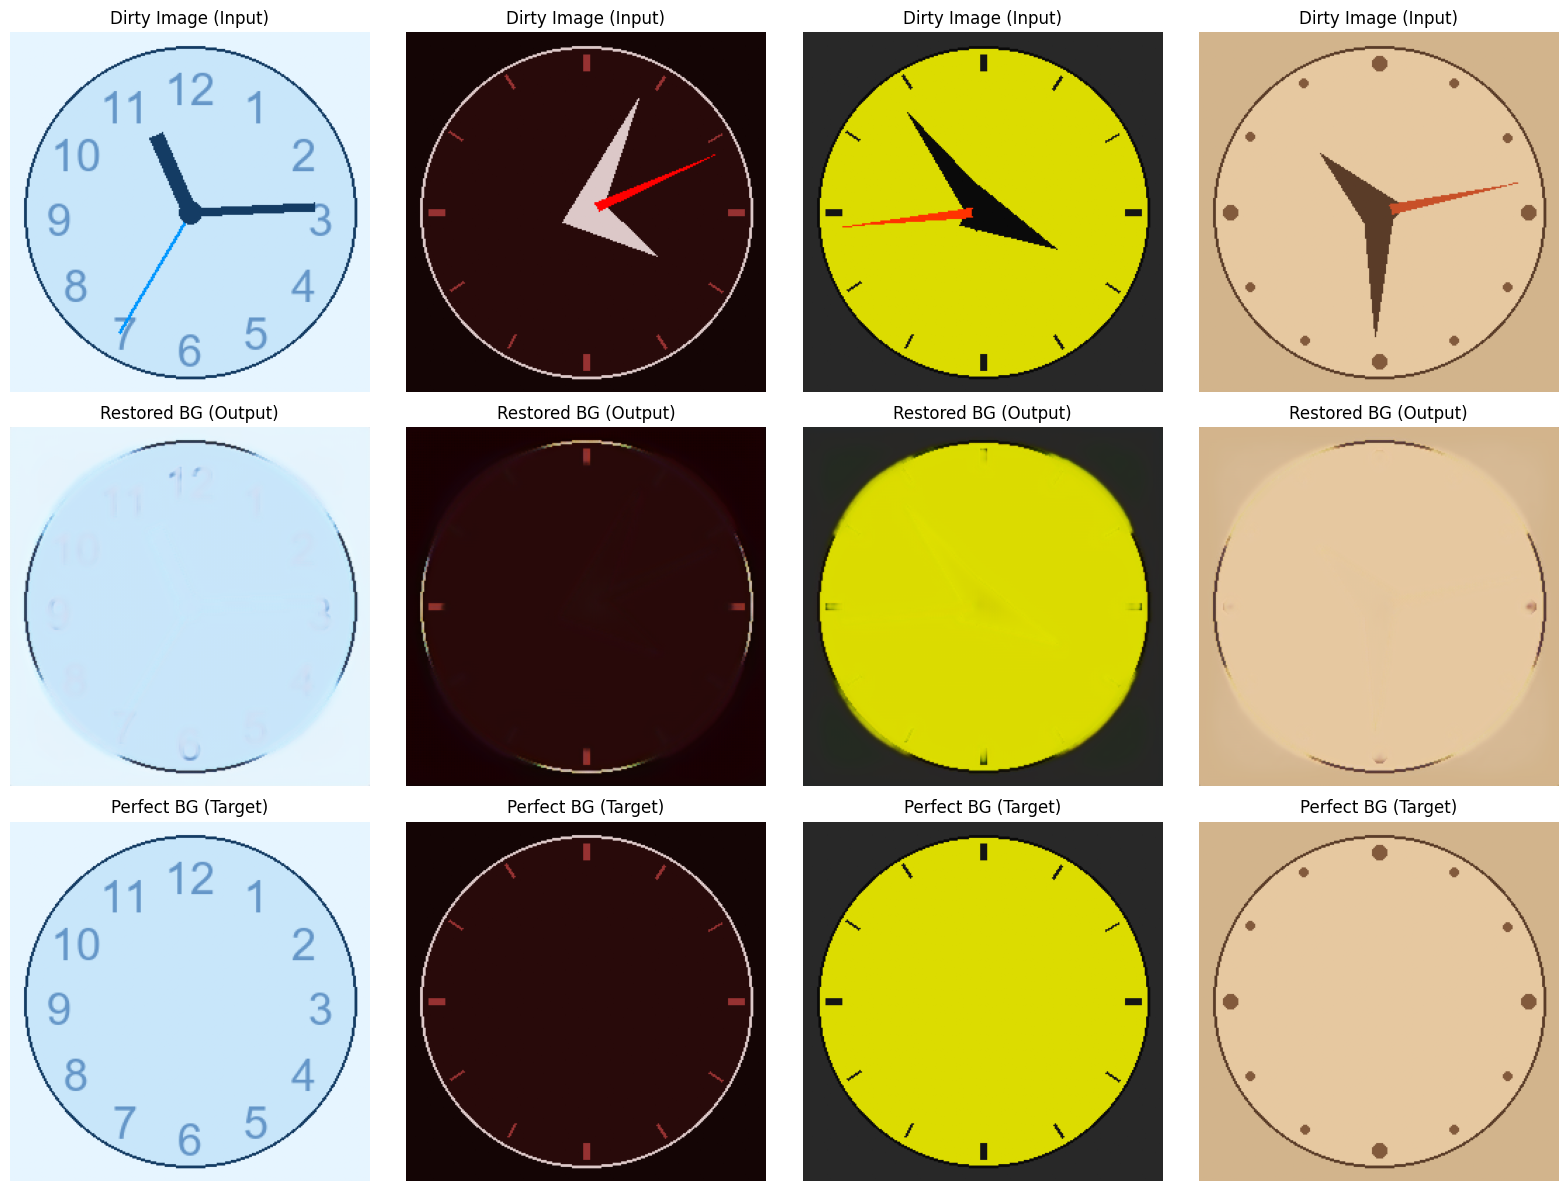

In [17]:
# ===================== CELL 9: EXECUTE EVALUATION =====================
if __name__ == "__main__":
    assess_visual_quality(target_dir='../datasets')